# Theoretical Foundations of Shor’s Algorithm for ECDLP

This notebook develops the theoretical foundations for applying Shor algorithm to the Elliptic Curve Discrete Logarithm Problem (ECDLP). The emphasis is on the mathematical structure of the algorithm: how an unknown scalar is transformed into a hidden linear relation, encoded as quantum phase information, extracted through Fourier interference, and recovered using classical modular arithmetic.

Throughout the derivation, the algorithm is treated as an ideal mathematical model. Exact order-$r$ quantum registers, an exact $QFT_r$, and abstract reversible elliptic-curve oracle blocks are assumed to illustrate the theoretical operation of the algorithm. The circuit diagrams are therefore conceptual representations of the computation rather than realizable gate-level quantum circuits.

The derivation is presented from first principles. Expandable background sections introduce the essential concepts of elliptic curve cryptography and quantum computing, while the main exposition follows the algorithm from the public elliptic-curve relation to the recovery of the discrete logarithm.

---

## Theoretical Scope

The notebook focuses on:

- elliptic-curve point addition and scalar multiplication;
- the Elliptic Curve Discrete Logarithm Problem (ECDLP);
- the hidden-relation function $f(a,b)=aG+bQ$;
- quantum control and worker registers;
- point-shift eigenstates and phase kickback;
- inverse Quantum Fourier Transform interference;
- measurement and classical recovery of the hidden scalar.

A deliberately small elliptic curve is used. Applying the same approach to practical elliptic-curve cryptography would require large-scale fault-tolerant quantum computers capable of implementing reversible elliptic-curve arithmetic.

---

## Problem Statement

Let $G$ be a generator of a cyclic elliptic-curve subgroup and let $Q$ be a public point satisfying

$$
Q=dG.
$$

The points $G$ and $Q$ are public; the scalar $d$ is unknown. The objective is to recover $d$.

For the running example,

$$
G=(199,192), \qquad Q=(62,206),
$$

and the derivation will recover and verify

$$
d=71.
$$

<details markdown="1">
<summary><strong>The ECC discrete-log problem</strong></summary>

A normal number multiplication problem looks like this:

$$
7 \cdot 10 = 70
$$

If $70$ and $10$ is given, it is easy to find $7$:

$$
70/10=7
$$

Elliptic curves do not work like ordinary multiplication. In ECC, the public key is made by repeatedly adding a point to itself:

$$
Q=dG
$$

This means:

$$
Q=G+G+G+\cdots+G
$$

where $G$ is added to itself $d$ times.

In this notebook:

$$
Q=71G
$$

The secret is $d = 71$, the private key. The public information is the generator point $G$ and the public key $Q$.

Given $G$ and $Q$, the goal is to recover the private key $d$.

The hard question is:

$$
G,Q \longrightarrow d
$$

This is the elliptic-curve discrete logarithm problem (ECDLP).

</details>


<details markdown="1">
<summary><strong>What is an elliptic-curve point?</strong></summary>

An elliptic curve over a finite field is the set of coordinate pairs that satisfy an equation. Its general form is

$$
y^2 \equiv x^3+ax+b \pmod p.
$$

Here, $a$ and $b$ are constants that define the shape of the curve, and $p$ is the prime modulus that defines the finite field. Different choices of $a$, $b$, and $p$ produce different elliptic curves.

For the small demonstration curve used in this notebook, we choose

$$
a=2, \qquad b=3, \qquad p=211.
$$

Substituting these values into the general equation gives our curve:

$$
y^2 \equiv x^3+2x+3 \pmod{211}.
$$

The notation $\pmod{211}$ means that after a calculation we keep only the remainder after division by $211$. Therefore the possible coordinate values are $0,1,2,\ldots,210$.

A point is an ordered pair

$$
P=(x,y)
$$

that makes the left and right sides of the curve equation equal modulo $211$. For example, the generator used in this notebook is

$$
G=(199,192).
$$

To verify that $G$ lies on the curve, substitute $x=199$ and $y=192$ into the equation.

Left side:

$$
y^2=192^2=36864
$$

Because

$$
211\cdot174=36714,
$$

the remainder is

$$
36864-36714=150.
$$

Therefore

$$
192^2 \equiv 150 \pmod{211}.
$$

Right side:

$$
199^3+2\cdot199+3=7{,}881{,}000.
$$

Because

$$
211\cdot37{,}350=7{,}880{,}850,
$$

the remainder is also

$$
7{,}881{,}000-7{,}880{,}850=150.
$$

Both sides reduce to the same value:

$$
150 \equiv 150 \pmod{211}.
$$

Therefore $G=(199,192)$ is a valid point on the curve.

### What the curve looks like

A real-number elliptic curve is usually drawn as a smooth, vase-shaped curve. Here the arithmetic is modulo $211$, so the picture is instead a finite collection of separate dots. Each blue dot is one valid pair $(x,y)$; the red star identifies the generator $G=(199,192)$ used throughout the notebook.

<img src="ss.png" alt="Graph of the elliptic curve points modulo 211 with G highlighted" width="720">

</details>

In [ ]:
p = 211
a = 2
b = 3
G = (199, 192)
r = 204

def mod(value):
    return value % p

def on_curve(P):
    x, y = P
    return mod(y*y) == mod(x*x*x + a*x + b)

print("G is on the curve:", on_curve(G))
print("left side y^2 mod p =", mod(G[1] * G[1]))
print("right side x^3+2x+3 mod p =", mod(G[0]**3 + a*G[0] + b))


<details markdown="1">
<summary><strong>ECC arithmetic: point addition</strong></summary>

If we have two different points:

$$
P=(x_1,y_1), \qquad R=(x_2,y_2)
$$

then the slope is:

$$
\lambda=\frac{y_2-y_1}{x_2-x_1}
$$

In modular arithmetic, division means multiplication by the modular inverse:

$$
\frac{A}{B}\pmod p = A\cdot B^{-1}\pmod p
$$

After finding $\lambda$, the new point is:

$$
x_3=\lambda^2-x_1-x_2
$$

$$
y_3=\lambda(x_1-x_3)-y_1
$$

Then apply modulo $p$ to the both coordinates $x_3$ and $y_3$ so that the resulting point remains in the finite field.

This is what the code function `point_add` does.

</details>


<details markdown="1">
<summary><strong>ECC arithmetic: point doubling</strong></summary>

Point doubling is the special case of point addition where both input points are the same:

$$
2P=P+P
$$

It is still point addition, but when the two points are the same the slope formula changes. For the curve

$$
y^2=x^3+ax+b
$$

the doubling slope is:

$$
\lambda=\frac{3x_1^2+a}{2y_1}
$$

Only the formula for $\lambda$ changes. After finding $\lambda$, point doubling uses the same coordinate formulas introduced in point addition:

$$
x_3=\lambda^2-x_1-x_2 \pmod p
$$

$$
y_3=\lambda(x_1-x_3)-y_1 \pmod p.
$$

Because point doubling has $P=R$, we have $x_2=x_1$, so the first formula can also be written as

$$
x_3=\lambda^2-2x_1 \pmod p.
$$

For $G=(199,192)$:

$$
\lambda=\frac{3\cdot199^2+2}{2\cdot192}\pmod {211}
$$

The result is:

$$
2G=(58,30)
$$

So the first repeated addition step is already visible:

$$
G+G=(58,30)
$$

</details>


In [ ]:
def inverse_mod(value):
    return pow(value % p, -1, p)

def point_add(P, R):
    if P is None:
        return R
    if R is None:
        return P

    x1, y1 = P
    x2, y2 = R

    if x1 == x2 and mod(y1 + y2) == 0:
        return None

    if P == R:
        numerator = 3*x1*x1 + a
        denominator = 2*y1
    else:
        numerator = y2 - y1
        denominator = x2 - x1

    slope = mod(numerator * inverse_mod(denominator))
    x3 = mod(slope*slope - x1 - x2)
    y3 = mod(slope*(x1 - x3) - y1)
    return (x3, y3)

print("2G =", point_add(G, G))


<details markdown="1">
<summary><strong>ECC arithmetic: scalar multiplication</strong></summary>

## Elliptic-Curve Scalar Multiplication

Scalar multiplication means repeatedly adding an elliptic-curve point. It is not ordinary multiplication and it is not the same operation as modular multiplication.

$$
3G=G+G+G
$$

$$
71G=G+G+\cdots+G
$$

with $G$ repeated $71$ times.

Doing $71$ additions one by one works, but it is slow. Computers use double-and-add.

Write $71$ in binary:

$$
71=64+4+2+1
$$

$$
71=(1000111)_2
$$

So:

$$
71G=64G+4G+2G+G
$$

This is still only point addition and point doubling. Modular arithmetic is used inside those operations to calculate and reduce the coordinates.

</details>


In [ ]:
def scalar_multiply(k, P=G):
    result = None
    addend = P
    value = k

    while value > 0:
        if value & 1:
            result = point_add(result, addend)
        addend = point_add(addend, addend)
        value >>= 1

    return result

for k in [1, 2, 3, 4, 8, 16, 32, 64, 71]:
    print(f"{k}G = {scalar_multiply(k)}")

Q = scalar_multiply(71)
print("Public key Q = 71G =", Q)

example_a = 2
example_b = 3
example_k = 5
private_d = 71
phase_exponent = example_k * (example_a + private_d * example_b) % r
measured_b = example_k * private_d % r
print("Oracle example phase exponent =", phase_exponent)
print("Example measurement pair (m_A, m_B) =", (example_k, measured_b))


<details markdown="1">
<summary><strong>Why ECDLP is hard classically?</strong></summary>

## Easy Forward, Hard to Reverse

Suppose the private key $d$ and generator point $G$ are known. Computing the public point is the **forward problem**:

$$
d,G \longrightarrow Q=dG.
$$

This is efficient: the double-and-add method computes $dG$ using point doubling and point addition.

Now suppose only $G$ and $Q$ are known. Recovering the private key is the **reverse problem**:

$$
G,Q \longrightarrow d.
$$

This reverse problem is the **elliptic-curve discrete logarithm problem (ECDLP)**:

$$
\text{Given }G\text{ and }Q=dG,\text{ find }d.
$$

Although $Q$ was created from $d$, the point $Q$ does not reveal how many additions produced it. Elliptic-curve points also have no division operation that simply reverses scalar multiplication. With the best known classical methods, recovering $d$ on a properly chosen cryptographic curve requires an infeasible amount of computation.

### Why use a tiny curve here?

Our demonstration group has order $204$, so a classical computer could test every possible value of $d$. This small size is intentional: it lets us calculate the points by hand and verify every result. Exhaustive search is only a way to check the example; it is not the method used in the Shor derivation that follows.

The rest of the notebook develops Shor's hidden-relation and measurement logic for this small instance. Applying the same approach to a real cryptographic curve would require a large fault-tolerant quantum computer and reversible elliptic-curve arithmetic circuits.

</details>


## Define the Hidden-Relation Function

The equation $Q=dG$ does not let us read $d$ directly. Shor's algorithm therefore rewrites the problem as a function with a repeating structure. Different input pairs produce the same curve point along a hidden direction determined by $d$.

This reformulation is important because the oracle can evaluate the hidden-relation function for many input pairs at the same time and encode its structure into the quantum state. The quantum part of the algorithm then uses interference and the inverse QFT to detect that hidden structure. Once the hidden relation is measured, classical modular algebra can recover $d$.

### Create the Function

For ECC discrete log, Shor's algorithm uses a two-input function:

$$
f(a,b)=aG+bQ
$$

The inputs $a$ and $b$ range over the group. Later, the quantum registers will represent these pairs in superposition rather than testing them one at a time.

Examples:

$$
f(1,0)=1G+0Q=G
$$

$$
f(0,1)=0G+1Q=Q
$$

$$
f(2,1)=2G+Q
$$

Now use the fact that $Q=dG$:

$$
f(a,b)=aG+b(dG)
$$

Because scalar multiplication distributes over point addition:

$$
aG+bdG=(a+bd)G
$$

Therefore:

$$
f(a,b)=(a+bd)G
$$

This is the crucial algebra. The secret $d$ is now inside a hidden linear relation.


### Where the Period Comes From

Suppose two pairs give the same point:

$$
f(a,b)=f(a',b')
$$

Substitute the formula:

$$
(a+bd)G=(a'+b'd)G
$$

If $G$ has order $r$, then two scalar multiples are equal when their scalars are equal modulo $r$:

$$
a+bd \equiv a'+b'd \pmod r
$$

Move everything to one side:

$$
(a'-a)+d(b'-b) \equiv 0 \pmod r
$$

So a period vector $(\Delta a,\Delta b)$ satisfies:

$$
\Delta a+d\Delta b\equiv0\pmod r
$$

We choose the vector $(-d,1)$ because moving in that direction leaves the function value unchanged.

Therefore one simple period vector is

$$
(-d,1)
$$

because:

$$
-d+d\cdot1=0
$$

Finding this hidden relation reveals $d$.


<details markdown="1">
<summary><strong>Quantum Registers</strong></summary>

A classical register stores one bit string.

Example:

$$
0110
$$

This stores one number: $6$.

A quantum bit, or qubit, can be in a superposition:

$$
\alpha|0\rangle+\beta|1\rangle
$$

The symbols $\alpha$ and $\beta$ are amplitudes. They are not probabilities yet. Probabilities appear when we measure:

$$
P(0)=|\alpha|^2, \qquad P(1)=|\beta|^2
$$

Two qubits can hold four basis states:

$$
|00\rangle, |01\rangle, |10\rangle, |11\rangle
$$

Three qubits hold eight basis states. Four qubits hold sixteen. In general:

$$
n\text{ qubits } \longrightarrow 2^n\text{ basis states}
$$

For the QPE-style ECC Shor explanation used in this notebook, we use two number registers:

$$
|a\rangle_A|b\rangle_B
$$

and one worker register $Y$ whose basis states encode elliptic-curve points such as $|jG\rangle$. The worker starts in the identity-point state:

$$
|0G\rangle_Y.
$$

This state is an equal superposition of the point-shift eigenstates $|\chi_k\rangle$. The controlled additions of $aG$ and $bQ$ act on every eigenstate component. Each component remains unchanged while its corresponding phase is written into registers $A$ and $B$. This is phase kickback, and it lets the algorithm sample an unknown value of $k$ without preparing or choosing $k$ in advance.

</details>


<details markdown="1">
<summary><strong>Initial State</strong></summary>

The two control registers start at zero. The worker register starts at the group identity, written $|0G\rangle_Y$.

The starting state is therefore:

$$
|0\rangle_A|0\rangle_B|0G\rangle_Y.
$$

Here:

- $A$ stores $a$.
- $B$ stores $b$.
- $Y$ is the point-encoded worker register used for phase kickback.

At this moment, $A$ and $B$ contain only zero. They must next be prepared uniformly over the values $0,1,\ldots,r-1$. When $r=204$, ordinary Hadamard gates alone cannot create that exact state because qubit Hadamards produce a power-of-two number of basis states. The ideal order-$204$ preparation used in the derivation is separated from the practical register-size discussion below.

</details>


<details markdown="1">
<summary><strong>Hadamard Gate</strong></summary>

The Hadamard gate creates superposition.

$$
H=\frac1{\sqrt2}\begin{bmatrix}1&1\\1&-1\end{bmatrix}
$$

The basis state $|0\rangle$ is the vector:

$$
|0\rangle=\begin{bmatrix}1\\0\end{bmatrix}
$$

Now multiply:

$$
H|0\rangle=\frac1{\sqrt2}\begin{bmatrix}1&1\\1&-1\end{bmatrix}\begin{bmatrix}1\\0\end{bmatrix}
$$

Line by line:

$$
\text{top}=1\cdot1+1\cdot0=1
$$

$$
\text{bottom}=1\cdot1+(-1)\cdot0=1
$$

So:

$$
H|0\rangle=\frac1{\sqrt2}\begin{bmatrix}1\\1\end{bmatrix}
$$

In ket notation:

$$
H|0\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

</details>


<details markdown="1">
<summary><strong>Tensor Product</strong></summary>

Registers combine using the tensor product.

$$
|0\rangle\otimes|0\rangle=|00\rangle
$$

As vectors:

$$
|0\rangle=\begin{bmatrix}1\\0\end{bmatrix}
$$

So:

$$
\begin{bmatrix}1\\0\end{bmatrix}\otimes\begin{bmatrix}1\\0\end{bmatrix}=\begin{bmatrix}1\cdot1\\1\cdot0\\0\cdot1\\0\cdot0\end{bmatrix}=\begin{bmatrix}1\\0\\0\\0\end{bmatrix}=|00\rangle
$$

If we apply Hadamard to both qubits:

$$
H|0\rangle\otimes H|0\rangle
$$

we get:

$$
\frac{|0\rangle+|1\rangle}{\sqrt2}\otimes\frac{|0\rangle+|1\rangle}{\sqrt2}
$$

Distribute the product:

$$
\frac{|00\rangle+|01\rangle+|10\rangle+|11\rangle}{2}
$$

For $n$ qubits:

$$
H^{\otimes n}|0\rangle^{\otimes n}=\frac1{\sqrt{2^n}}\sum_{x=0}^{2^n-1}|x\rangle
$$

</details>


## Quantum Phase Extraction

The preceding section showed that the hidden relation is encoded by

$$
f(a,b)=aG+bQ=(a+bd)G.
$$

This section follows one uninterrupted quantum flow:

$$
\text{registers}\rightarrow\text{superposition}\rightarrow\text{oracle}\rightarrow\text{phase kickback}\rightarrow\text{inverse QFT}.
$$

### Model used in the main derivation

To keep the algebra exact, the main derivation first uses ideal registers with dimension

$$
r=204,
$$

the order of $G$. Consequently, the sums run from $0$ to $r-1$ and the transform is $QFT_r$. This is an ideal mathematical model; ordinary Hadamard gates on eight qubits would instead create $256$ basis states. Power-of-two registers and approximate phase recovery are discussed in the practical register-size section below.


### Define the Registers

We use three registers:

- $A$ stores the exponent $a$;
- $B$ stores the exponent $b$;
- $Y$ is the worker register on which elliptic-curve point shifts act.

The initial state is

$$
|0\rangle_A|0\rangle_B|0G\rangle_Y.
$$

No eigenstate label $k$ is selected or supplied in advance. The eigenstate-decomposition subsection will decompose $|0G\rangle_Y$ into all eigenstate components, and measurement will sample one of them. We later follow the component $k=5$ only as a concrete successful outcome.


### Create Superposition in the Control Registers

Prepare both ideal control registers uniformly over $\mathbb Z_r$:

$$
|0\rangle_A\longrightarrow\frac1{\sqrt r}\sum_{a=0}^{r-1}|a\rangle_A,
$$

$$
|0\rangle_B\longrightarrow\frac1{\sqrt r}\sum_{b=0}^{r-1}|b\rangle_B.
$$

The complete state before the oracle is therefore

$$
\frac1r\sum_{a=0}^{r-1}\sum_{b=0}^{r-1}
|a\rangle_A|b\rangle_B|0G\rangle_Y.
$$


### Decompose the Worker into Point-Shift Eigenstates

Define the point-shift operator

$$
U_G|jG\rangle=|(j+1)G\rangle
$$

and let

$$
\omega_r=e^{2\pi i/r}.
$$

For each $k\in\{0,1,\ldots,r-1\}$, define the Fourier eigenstate

$$
|\chi_k\rangle=\frac1{\sqrt r}\sum_{j=0}^{r-1}\omega_r^{-kj}|jG\rangle.
$$

It satisfies

$$
U_G|\chi_k\rangle=\omega_r^k|\chi_k\rangle.
$$

The identity-point state is an equal superposition of all these eigenstates:

$$
|0G\rangle=\frac1{\sqrt r}\sum_{k=0}^{r-1}|\chi_k\rangle.
$$

Therefore the algorithm does not need to know or prepare a particular $k$. It starts with $|0G\rangle$ and processes all $k$ components coherently. For each component, a point shift leaves the eigenstate unchanged and contributes only a phase. The point-shift eigenvalue appendix proves this identity.


### Construct the Controlled Oracle

The oracle applies point shifts controlled by $a$ and $b$:

$$
U_C(a,b)=U_G^aU_Q^b.
$$

Because $Q=dG$,

$$
U_Q=U_G^d
$$

and therefore

$$
U_Q|\chi_k\rangle=\omega_r^{kd}|\chi_k\rangle.
$$

In a circuit, binary digits of $a$ control the shifts $U_G,U_G^2,U_G^4,\ldots$, while binary digits of $b$ control $U_Q,U_Q^2,U_Q^4,\ldots$. Each shift requires reversible elliptic-curve arithmetic and uncomputation of temporary workspace. The controlled-unitary appendix reviews the general controlled-$U$ matrix.


### Quantum Circuit

Run the helper below to render the schematic quantum circuit used throughout the derivation. The displayed registers are drawn compactly to show the flow of the algorithm; they are not literal three-qubit implementations of the $r=204$ ideal registers. The blocks labeled $U_G^a$ and $U_Q^b$ represent reversible controlled elliptic-curve point-shift operations. They are shown as oracle blocks because a complete fault-tolerant decomposition into elementary quantum gates would require additional ancilla qubits, reversible elliptic-curve arithmetic, and uncomputation.

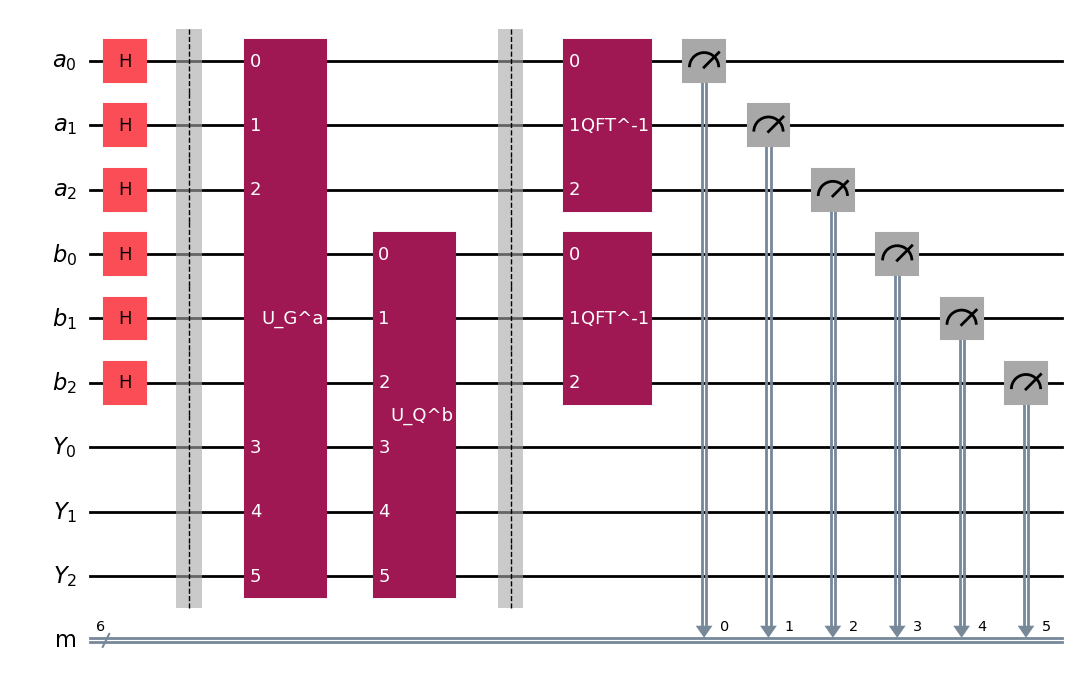

In [2]:
def _display_svg(svg_text):
    try:
        from IPython.display import SVG, display
        display(SVG(svg_text))
    except Exception:
        print(svg_text)

def draw_shor_ecc_circuit():
    try:
        from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
        from IPython.display import display
        from qiskit.circuit import Gate
        try:
            from qiskit.synthesis.qft import synth_qft_full
        except Exception:
            synth_qft_full = None

        a_reg = QuantumRegister(3, "a")
        b_reg = QuantumRegister(3, "b")
        y_reg = QuantumRegister(3, "Y")
        c_reg = ClassicalRegister(6, "m")
        qc = QuantumCircuit(a_reg, b_reg, y_reg, c_reg)

        qc.h(a_reg)
        qc.h(b_reg)
        qc.barrier()
        qc.append(Gate("U_G^a", len(a_reg) + len(y_reg), []), list(a_reg) + list(y_reg))
        qc.append(Gate("U_Q^b", len(b_reg) + len(y_reg), []), list(b_reg) + list(y_reg))
        qc.barrier()

        if synth_qft_full is not None:
            qc.append(synth_qft_full(len(a_reg), inverse=True, do_swaps=False).to_gate(label="QFT^-1"), a_reg)
            qc.append(synth_qft_full(len(b_reg), inverse=True, do_swaps=False).to_gate(label="QFT^-1"), b_reg)
        else:
            qc.append(Gate("QFT^-1", len(a_reg), []), a_reg)
            qc.append(Gate("QFT^-1", len(b_reg), []), b_reg)

        qc.measure(a_reg, c_reg[:3])
        qc.measure(b_reg, c_reg[3:])
        print("Schematic circuit: compact drawn registers show algorithm flow; the ideal derivation uses order-r registers with r=204, not literal 3-qubit registers.")
        display(qc.draw("mpl", fold=-1))
    except Exception as exc:
        svg = """<svg xmlns="http://www.w3.org/2000/svg" width="920" height="300" viewBox="0 0 920 300">
<style>
.label{font:14px sans-serif}.small{font:12px sans-serif;fill:#444}.gate{fill:#f7f7f7;stroke:#111;stroke-width:1.5}.wire{stroke:#111;stroke-width:1.4}
</style>
<text x="20" y="65" class="label">A register</text><line x1="120" y1="60" x2="850" y2="60" class="wire"/>
<text x="20" y="145" class="label">B register</text><line x1="120" y1="140" x2="850" y2="140" class="wire"/>
<text x="20" y="225" class="label">Y worker</text><line x1="120" y1="220" x2="850" y2="220" class="wire"/>
<rect x="145" y="35" width="95" height="130" class="gate"/><text x="192" y="88" text-anchor="middle" class="label">uniform</text><text x="192" y="108" text-anchor="middle" class="label">superposition</text>
<rect x="290" y="40" width="105" height="205" class="gate"/><text x="342" y="147" text-anchor="middle" class="label">U_G^a</text>
<rect x="440" y="75" width="105" height="170" class="gate"/><text x="492" y="165" text-anchor="middle" class="label">U_Q^b</text>
<rect x="600" y="30" width="85" height="60" class="gate"/><text x="642" y="65" text-anchor="middle" class="label">QFT^-1</text>
<rect x="600" y="110" width="85" height="60" class="gate"/><text x="642" y="145" text-anchor="middle" class="label">QFT^-1</text>
<rect x="735" y="35" width="90" height="130" class="gate"/><text x="780" y="108" text-anchor="middle" class="label">measure</text>
<text x="455" y="260" text-anchor="middle" class="small">Schematic only: compact drawn registers show algorithm flow, not literal 3-qubit order-204 registers.</text>
<text x="455" y="278" text-anchor="middle" class="small">Oracle blocks represent reversible controlled ECC point shifts, not expanded elementary gates.</text>
</svg>"""
        _display_svg(svg)
        print("Rendered fallback circuit diagram because Qiskit drawing was unavailable:", exc)

draw_shor_ecc_circuit()


### Apply the Oracle and Obtain Phase Kickback

Apply the oracle to one basis branch:

$$
|a\rangle_A|b\rangle_B|\chi_k\rangle_Y
\longrightarrow
|a\rangle_A|b\rangle_BU_G^aU_Q^b|\chi_k\rangle_Y.
$$

Using the eigenvalue relations,

$$
U_G^a|\chi_k\rangle=\omega_r^{ka}|\chi_k\rangle,
\qquad
U_Q^b|\chi_k\rangle=\omega_r^{kdb}|\chi_k\rangle.
$$

Thus

$$
|a\rangle_A|b\rangle_B|\chi_k\rangle_Y
\longrightarrow
\omega_r^{k(a+db)}|a\rangle_A|b\rangle_B|\chi_k\rangle_Y.
$$

For this one $k$ component, the worker is unchanged and the phase has been kicked back to the control registers. Now include every component in the decomposition of $|0G\rangle$. Applied to the complete state, the oracle produces

$$
\frac1{r\sqrt r}\sum_{k=0}^{r-1}\sum_{a=0}^{r-1}\sum_{b=0}^{r-1}
 e^{2\pi i ka/r}e^{2\pi i kdb/r}
|a\rangle_A|b\rangle_B|\chi_k\rangle_Y.
$$

Within each $k$ component, the control state factors into two Fourier waves: register $A$ has frequency $k/r$, and register $B$ has frequency $kd/r$.


<details markdown="1">
<summary><strong>Show calculation: oracle phase for a=2, b=3, k=5</strong></summary>

### Numerical Oracle-Phase Example

Now use real numbers from the demo.

The hidden private key is:

$$
d=71
$$

The group order in the demo is:

$$
r=204
$$

Follow one possible eigenstate component:

$$
k=5
$$

Choose one branch from the superposition:

$$
a=2, \qquad b=3
$$

The oracle phase is:

$$
\omega_r^{k(a+db)}
$$

First compute the inside part:

$$
a+db=2+71\cdot3
$$

Multiply:

$$
71\cdot3=213
$$

Add:

$$
2+213=215
$$

So:

$$
a+db=215
$$

Because phases are modulo $r=204$:

$$
215\equiv11\pmod{204}
$$

Now multiply by $k=5$:

$$
k(a+db)=5\cdot215
$$

Calculate:

$$
5\cdot215=1075
$$

Reduce modulo $204$:

$$
204\cdot5=1020
$$

$$
1075-1020=55
$$

So:

$$
k(a+db)\equiv55\pmod{204}
$$

Therefore this branch receives the phase:

$$
\omega_{204}^{55}
$$

Equivalently:

$$
\omega_{204}^{55}=e^{2\pi i\cdot55/204}
$$

Now check the same result by splitting the oracle into two parts.

First part:

$$
U_G^a=U_G^2
$$

Its phase is:

$$
\omega_{204}^{ka}=\omega_{204}^{5\cdot2}=\omega_{204}^{10}
$$

Second part:

$$
U_Q^b=U_Q^3
$$

Its phase is:

$$
\omega_{204}^{kdb}=\omega_{204}^{5\cdot71\cdot3}
$$

Calculate:

$$
5\cdot71\cdot3=1065
$$

Reduce modulo $204$:

$$
1065-1020=45
$$

So the second phase is:

$$
\omega_{204}^{45}
$$

Multiply both oracle phases:

$$
\omega_{204}^{10}\omega_{204}^{45}=\omega_{204}^{10+45}
$$

Therefore:

$$
\omega_{204}^{10}\omega_{204}^{45}=\omega_{204}^{55}
$$

This matches the direct calculation.

So for the branch $a=2,b=3,k=5$, the oracle does this:

$$
|2\rangle_A|3\rangle_B|\chi_5\rangle_Y
\longrightarrow
\omega_{204}^{55}|2\rangle_A|3\rangle_B|\chi_5\rangle_Y
$$

</details>


### Apply the Inverse QFT

The inverse Fourier transform converts each phase wave into a basis value:

$$
QFT_r^{-1}\left(\frac1{\sqrt r}\sum_{a=0}^{r-1}e^{2\pi i ka/r}|a\rangle\right)=|k\rangle,
$$

$$
QFT_r^{-1}\left(\frac1{\sqrt r}\sum_{b=0}^{r-1}e^{2\pi i kdb/r}|b\rangle\right)=|kd\bmod r\rangle.
$$

Applying these transforms to every $k$ component gives the complete ideal state

$$
\frac1{\sqrt r}\sum_{k=0}^{r-1}|k\rangle_A|kd\bmod r\rangle_B|\chi_k\rangle_Y.
$$

Measuring the control registers samples each value of $k$ with probability $1/r$ and returns the pair

$$
(m_A,m_B)=(k,kd\bmod r).
$$

The outcome $k=0$ gives $(0,0)$ and contains no information about $d$. If $\gcd(k,r)\ne1$, then $k$ has no modular inverse and one measurement may leave several possible values of $d$; the algorithm must combine additional measurements and verify the candidates. A run with $\gcd(k,r)=1$ allows direct recovery.

For $r=204$, $d=71$, and one successful sampled value $k=5$,

$$
kd\bmod r=5\cdot71\bmod204=151.
$$

The corresponding control-register outcome is

$$
|5\rangle_A|151\rangle_B.
$$

The inverse-QFT matrix appendix shows the matrix multiplication and interference explicitly.


### Fourier Peak Visualization

The ideal derivation with $r$-dimensional registers produces exact spikes at $k$ and $kd \bmod r$. With ordinary $N=2^n$ qubit registers, the inverse QFT instead gives a peaked distribution around the nearest integer to $N k/r$. Run the helper below to render that Fourier-interference peak shape.


Example values: k=5, d=71, r=204
A register phase location: N*k/r = 6.275
B register phase location: N*(k*d mod r)/r = 189.490
Ideal measurement pair: (5, 151)


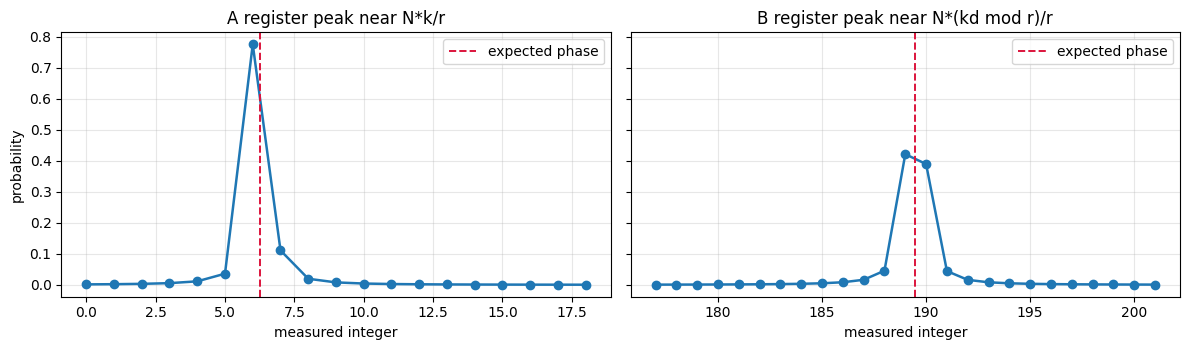

In [ ]:
import math
import cmath

def qft_peak_distribution(N, phase_fraction):
    probabilities = []
    for measured in range(N):
        amplitude = 0j
        for x in range(N):
            amplitude += cmath.exp(
                2j * math.pi * x * (phase_fraction - measured / N)
            )
        probabilities.append(abs(amplitude / N) ** 2)

    total = sum(probabilities)
    return [p / total for p in probabilities]


def _display_svg(svg_text):
    try:
        from IPython.display import SVG, display
        display(SVG(svg_text))
    except Exception:
        print(svg_text)


def _fourier_svg(series):
    width = 920
    height = 320
    panel_w = 420
    panel_h = 190
    top = 55
    lefts = [55, 495]

    max_prob = max(max(item["ys"]) for item in series)

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" '
        f'width="{width}" height="{height}" '
        f'viewBox="0 0 {width} {height}">'
    ]

    parts.append("""
    <style>
    .label{font:14px sans-serif}
    .small{font:12px sans-serif;fill:#444}
    .axis{stroke:#222;stroke-width:1}
    .curve{fill:none;stroke:#1f77b4;stroke-width:2}
    </style>
    """)

    for idx, item in enumerate(series):

        left = lefts[idx]
        bottom = top + panel_h

        xs = item["xs"]
        ys = item["ys"]

        x_min = min(xs)
        x_max = max(xs)

        def sx(x):
            return left + (x - x_min) * panel_w / max(1, x_max - x_min)

        def sy(y):
            return bottom - y * panel_h / max_prob

        points = " ".join(
            f"{sx(x):.1f},{sy(y):.1f}"
            for x, y in zip(xs, ys)
        )

        parts.append(
            f'<text x="{left + panel_w/2}" '
            f'y="28" text-anchor="middle" '
            f'class="label">{item["title"]}</text>'
        )

        parts.append(
            f'<line x1="{left}" y1="{bottom}" '
            f'x2="{left + panel_w}" y2="{bottom}" class="axis"/>'
        )

        parts.append(
            f'<line x1="{left}" y1="{top}" '
            f'x2="{left}" y2="{bottom}" class="axis"/>'
        )

        parts.append(
            f'<polyline points="{points}" class="curve"/>'
        )

        parts.append(
            f'<text x="{left}" y="{bottom + 28}" '
            f'class="small">Measured Integer</text>'
        )

    parts.append("</svg>")

    return "".join(parts)


def draw_fourier_peak_visualization(
    N=256,
    example_k=5,
    example_d=71,
    group_order=204,
):

    phase_a = example_k / group_order
    phase_b = ((example_k * example_d) % group_order) / group_order

    prob_a = qft_peak_distribution(N, phase_a)
    prob_b = qft_peak_distribution(N, phase_b)

    expected_a = N * phase_a
    expected_b = N * phase_b

    series = []

    for probs, expected, title in [

        (
            prob_a,
            expected_a,
            "A Register Measurement Distribution",
        ),

        (
            prob_b,
            expected_b,
            "B Register Measurement Distribution",
        ),

    ]:

        center = int(round(expected))

        left = max(0, center - 12)
        right = min(N - 1, center + 12)

        xs = list(range(left, right + 1))
        ys = [probs[x] for x in xs]

        series.append(
            {
                "xs": xs,
                "ys": ys,
                "title": title,
            }
        )

    try:

        import matplotlib.pyplot as plt

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12, 3.6),
            sharey=True,
        )

        for ax, item in zip(axes, series):

            ax.plot(
                item["xs"],
                item["ys"],
                marker="o",
                linewidth=2,
            )

            ax.set_title(item["title"])

            ax.set_xlabel("Measured Integer")

            ax.set_ylabel("Probability")

            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except Exception:

        _display_svg(_fourier_svg(series))


draw_fourier_peak_visualization()

## Measurement and Classical Recovery

After the inverse QFT, measure the two control registers and solve their modular relation.

For the running example, one successful sampled measurement is

$$
m_A=5,\qquad m_B=151.
$$

With an eight-bit encoding, these values appear as

$$
5=(00000101)_2,
\qquad
151=(10010111)_2.
$$

They satisfy

$$
m_B\equiv m_A d\pmod r.
$$


<details markdown="1">
<summary><strong>How the measured values are phase estimates</strong></summary>

The derivation above uses the ideal transform $QFT_r$, where $r=204$ is the exact order of the demonstration point. In an ordinary quantum circuit, the control registers usually have $n$ qubits each, so each register has

$$
N=2^n
$$

basis states. In that more standard QPE view, the same ECC discrete-log problem is expressed with two controlled unitary operators:

$$
U_G|jG\rangle=|(j+1)G\rangle,
$$

and

$$
U_Q|jG\rangle=|jG+Q\rangle.
$$

Since $Q=dG$, the second operation is also

$$
U_Q|jG\rangle=|(j+d)G\rangle.
$$

For a point-shift eigenstate $|\chi_k\rangle$, these two unitary operators have phases

$$
U_G|\chi_k\rangle=e^{2\pi i k/r}|\chi_k\rangle,
$$

and

$$
U_Q|\chi_k\rangle=e^{2\pi i kd/r}|\chi_k\rangle.
$$

Therefore two separate QPE control registers estimate two phases:

$$
\phi_1 \equiv \frac{k}{r}\pmod 1,
\qquad
\phi_2 \equiv \frac{kd}{r}\pmod 1.
$$

After the inverse Fourier transform on the two $n$-qubit control registers, the measured integers $y_1$ and $y_2$ satisfy approximately

$$
\phi_1 \approx \frac{y_1}{2^n}\pmod 1,
\qquad
\phi_2 \approx \frac{y_2}{2^n}\pmod 1.
$$

A classical post-processing step converts these phase estimates into modular information about $k$ and $kd$. In the idealized $QFT_r$ derivation used earlier, this approximation disappears and the same idea is written directly as

$$
(m_A,m_B)=(k,kd\bmod r).
$$

This is why the notebook uses two control registers and one elliptic-curve worker register. One control register probes shifts by $G$, the other probes shifts by $Q$, and their measured relationship reveals the discrete logarithm $d$.

</details>


### Recover the Private Key

The example gives

$$
151\equiv5d\pmod{204}.
$$

The simple inverse formula is valid only when

$$
\gcd(m_A,r)=1.
$$

Here $\gcd(5,204)=1$ and

$$
5^{-1}\equiv41\pmod{204}.
$$

Therefore

$$
d\equiv151\cdot41\equiv71\pmod{204}.
$$

If $m_A$ is not invertible modulo $r$, one cannot use this formula directly. The congruence may have multiple candidates, and another independent measurement is normally required.


### Verify the Result

Check the recovered scalar against the public point:

$$
71G=(62,206)=Q.
$$

The recovered private key is therefore

$$
\boxed{d=71}.
$$


## Practical Register Sizes and Approximate Measurements

The exact derivation above uses $r$-dimensional registers and $QFT_r$. Physical qubit registers normally have dimension

$$
N=2^n.
$$

When $N$ is not equal to $r$, the measured phases are approximations to rational values associated with $k/r$ and $kd/r$. Sufficiently large registers, rational reconstruction such as continued fractions, validation of candidate relations, and usually repeated samples are required.

Therefore, eight qubits are enough to *store* the integers $0$ through $203$, but an ordinary eight-qubit Hadamard state is uniform over $256$ values and does not implement the exact $204$-dimensional derivation. This notebook keeps the ideal derivation separate from that implementation issue.


<details markdown="1">
<summary><strong>Optional context: what recovered d means for encryption</strong></summary>

## Optional Cryptographic Context

Once the private key is recovered, the rest is ordinary cryptography.

Suppose Alice sent a message to Bob.

The sender has private key $d_A$ and public key:

$$
Q_A=d_AG
$$

The receiver has private key $d_B$ and public key:

$$
Q_B=d_BG
$$

ECDH shared secret from Alice's side:

$$
S=d_AQ_B
$$

Substitute $Q_B=d_BG$:

$$
S=d_A(d_BG)
$$

$$
S=d_Ad_BG
$$

ECDH shared secret from Bob's side:

$$
S=d_BQ_A=d_B(d_AG)=d_Bd_AG
$$

Since scalar multiplication commutes at the scalar level:

$$
d_Ad_BG=d_Bd_AG
$$

both sides get the same point $S$.

If an attacker recovers Bob's private key $d_B$, the attacker computes:

$$
S=d_BQ_A
$$

Then the attacker derives the AES key using SHA-256 and decrypts with AES-GCM.

Important boundary:

- The ECC scalar multiplication in your educational notebook is your own implementation.
- SHA-256 hashing is provided by Python's `hashlib`.
- AES-GCM decryption is provided by PyCryptodome's `Crypto.Cipher.AES`.
- AES is not broken. The weak public-key exchange is what exposes the AES key.

</details>


## Appendix: Proof of the Point-Shift Eigenvalue

This appendix proves the identity used in the eigenstate-decomposition subsection.


### Detailed Eigenstate Derivation

The worker register uses a special state called an eigenstate.

First define a point-shift operation by $G$:

$$
U_G|jG\rangle=|(j+1)G\rangle
$$

This means: if the worker contains $jG$, then $U_G$ adds one more $G$.

Define:

$$
\omega_r=e^{2\pi i/r}
$$

The eigenstate is:

$$
|\chi_k\rangle=\frac{1}{\sqrt r}\sum_{j=0}^{r-1}\omega_r^{-kj}|jG\rangle
$$

Now apply $U_G$ to it:

$$
U_G|\chi_k\rangle
=
U_G\left(\frac{1}{\sqrt r}\sum_{j=0}^{r-1}\omega_r^{-kj}|jG\rangle\right)
$$

Move $U_G$ inside the sum:

$$
U_G|\chi_k\rangle
=
\frac{1}{\sqrt r}\sum_{j=0}^{r-1}\omega_r^{-kj}U_G|jG\rangle
$$

Use $U_G|jG\rangle=|(j+1)G\rangle$:

$$
U_G|\chi_k\rangle
=
\frac{1}{\sqrt r}\sum_{j=0}^{r-1}\omega_r^{-kj}|(j+1)G\rangle
$$

Let:

$$
\ell=j+1
$$

Then:

$$
j=\ell-1
$$

Substitute into the sum:

$$
U_G|\chi_k\rangle
=
\frac{1}{\sqrt r}\sum_{\ell=0}^{r-1}\omega_r^{-k(\ell-1)}|\ell G\rangle
$$

Now simplify the exponent:

$$
-k(\ell-1)=-k\ell+k
$$

So:

$$
\omega_r^{-k(\ell-1)}=\omega_r^{-k\ell+k}
$$

Use the exponent rule $x^{a+b}=x^a x^b$:

$$
\omega_r^{-k\ell+k}=\omega_r^{-k\ell}\omega_r^k
$$

Therefore:

$$
U_G|\chi_k\rangle
=
\frac{1}{\sqrt r}\sum_{\ell=0}^{r-1}\omega_r^{-k\ell}\omega_r^k|\ell G\rangle
$$

The factor $\omega_r^k$ does not depend on $\ell$, so pull it outside:

$$
U_G|\chi_k\rangle
=
\omega_r^k\frac{1}{\sqrt r}\sum_{\ell=0}^{r-1}\omega_r^{-k\ell}|\ell G\rangle
$$

The remaining sum is exactly $|\chi_k\rangle$:

$$
U_G|\chi_k\rangle=\omega_r^k|\chi_k\rangle
$$

This is why the eigenstate is useful. The worker register stays the same, but a phase appears.


## Appendix: Controlled-Unitary Matrix Details

These matrix examples explain the general controlled-operation mechanism. They are not additional stages of Shor's algorithm.


### Controlled-$U$ Matrix

Before phase kickback, we need the actual controlled-$U$ matrix.

Controlled-$U$ means:

- if the control qubit is $0$, do nothing;
- if the control qubit is $1$, apply $U$ to the target.

As an operator:

$$
CU=|0\rangle\langle0|\otimes I+|1\rangle\langle1|\otimes U
$$

Now write the two projectors:

$$
|0\rangle\langle0|=
\begin{bmatrix}
1&0\\
0&0
\end{bmatrix}
$$

$$
|1\rangle\langle1|=
\begin{bmatrix}
0&0\\
0&1
\end{bmatrix}
$$

So:

$$
CU=
\begin{bmatrix}
1&0\\
0&0
\end{bmatrix}\otimes I
+
\begin{bmatrix}
0&0\\
0&1
\end{bmatrix}\otimes U
$$

This becomes the block matrix:

$$
CU=
\begin{bmatrix}
I&0\\
0&U
\end{bmatrix}
$$

If the target is one qubit and:

$$
U=\begin{bmatrix}
u_{00}&u_{01}\\
u_{10}&u_{11}
\end{bmatrix}
$$

then:

$$
CU=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&u_{00}&u_{01}\\
0&0&u_{10}&u_{11}
\end{bmatrix}
$$

The basis order is:

$$
|00\rangle, |01\rangle, |10\rangle, |11\rangle
$$

The first bit is the control. The second bit is the target.


### Controlled-$Z$ Example

Use a concrete one-qubit target operation:

$$
U=Z=
\begin{bmatrix}
1&0\\
0&-1
\end{bmatrix}
$$

Then controlled-$Z$ is:

$$
CZ=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&1&0\\
0&0&0&-1
\end{bmatrix}
$$

Now apply it to each basis vector.

First:

$$
|00\rangle=
\begin{bmatrix}
1\\0\\0\\0
\end{bmatrix}
$$

Multiply:

$$
CZ|00\rangle=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&1&0\\
0&0&0&-1
\end{bmatrix}
\begin{bmatrix}
1\\0\\0\\0
\end{bmatrix}
=
\begin{bmatrix}
1\\0\\0\\0
\end{bmatrix}
=|00\rangle
$$

Control is $0$, so nothing happens.

Second:

$$
|01\rangle=
\begin{bmatrix}
0\\1\\0\\0
\end{bmatrix}
$$

$$
CZ|01\rangle=
\begin{bmatrix}
0\\1\\0\\0
\end{bmatrix}
=|01\rangle
$$

Control is still $0$, so nothing happens.

Third:

$$
|10\rangle=
\begin{bmatrix}
0\\0\\1\\0
\end{bmatrix}
$$

$$
CZ|10\rangle=
\begin{bmatrix}
0\\0\\1\\0
\end{bmatrix}
=|10\rangle
$$

Control is $1$, so $Z$ is applied to the target. But the target is $|0\rangle$, and $Z|0\rangle=|0\rangle$.

Fourth:

$$
|11\rangle=
\begin{bmatrix}
0\\0\\0\\1
\end{bmatrix}
$$

$$
CZ|11\rangle=
\begin{bmatrix}
0\\0\\0\\-1
\end{bmatrix}
=-|11\rangle
$$

Control is $1$, target is $|1\rangle$, and $Z|1\rangle=-|1\rangle$.

So only $|11\rangle$ receives a phase of $-1$.

This is the same controlled-operation idea used in the Shor oracle, except the target operation is not a simple $Z$ gate. It is a controlled elliptic-curve shift such as $U_G^{2^j}$ or $U_Q^{2^j}$.


## Appendix: Detailed ECC Arithmetic Inside the Oracle

This appendix verifies the point calculation used by the numerical oracle example.


<details markdown="1">
<summary><strong>Show calculation: actual ECC point arithmetic inside the oracle</strong></summary>

### ECC Point-Arithmetic Calculation

The previous section calculated the phase. Now calculate the curve point itself for the same branch:

$$
a=2, \qquad b=3, \qquad d=71
$$

The oracle function is:

$$
f(a,b)=aG+bQ
$$

So for this branch:

$$
f(2,3)=2G+3Q
$$

We already know:

$$
Q=71G=(62,206)
$$

First compute:

$$
2G=(58,30)
$$

Next compute $3Q$.

One $Q$ is:

$$
Q=(62,206)
$$

Two $Q$ is:

$$
2Q=(72,145)
$$

Three $Q$ is:

$$
3Q=2Q+Q=(91,203)
$$

Now add:

$$
2G+3Q=(58,30)+(91,203)
$$

Use the point-addition slope formula:

$$
\lambda=\frac{y_2-y_1}{x_2-x_1}\pmod{211}
$$

Substitute the numbers:

$$
\lambda=\frac{203-30}{91-58}\pmod{211}
$$

Compute numerator and denominator:

$$
203-30=173
$$

$$
91-58=33
$$

So:

$$
\lambda=173\cdot33^{-1}\pmod{211}
$$

The modular inverse is:

$$
33^{-1}\equiv32\pmod{211}
$$

because:

$$
33\cdot32=1056
$$

and:

$$
1056\equiv1\pmod{211}
$$

Now compute the slope:

$$
\lambda=173\cdot32=5536
$$

Reduce modulo $211$:

$$
211\cdot26=5486
$$

$$
5536-5486=50
$$

So:

$$
\lambda=50
$$

Now compute the new $x$ coordinate:

$$
x_3=\lambda^2-x_1-x_2
$$

Substitute:

$$
x_3=50^2-58-91
$$

Calculate:

$$
50^2=2500
$$

$$
2500-58-91=2351
$$

Reduce modulo $211$:

$$
211\cdot11=2321
$$

$$
2351-2321=30
$$

So:

$$
x_3=30
$$

Now compute the new $y$ coordinate:

$$
y_3=\lambda(x_1-x_3)-y_1
$$

Substitute:

$$
y_3=50(58-30)-30
$$

Calculate:

$$
58-30=28
$$

$$
50\cdot28=1400
$$

$$
1400-30=1370
$$

Reduce modulo $211$:

$$
211\cdot6=1266
$$

$$
1370-1266=104
$$

So:

$$
y_3=104
$$

Therefore:

$$
2G+3Q=(30,104)
$$

Now check with the hidden-secret form:

$$
a+bd=2+3\cdot71=215
$$

Since the order is $204$:

$$
215\equiv11\pmod{204}
$$

So:

$$
(a+bd)G=215G=11G
$$

And direct scalar multiplication gives:

$$
11G=(30,104)
$$

So both paths match:

$$
f(2,3)=2G+3Q=(a+bd)G=11G=(30,104)
$$

This is the concrete arithmetic that the oracle is representing reversibly.

</details>


## Appendix: Inverse-QFT Matrix and Interference

This appendix proves the inverse-QFT result used earlier with a small matrix example.


### Fourier Transform and Inverse Fourier Transform

To see how the inverse QFT converts phase into a measurable value, we use its matrix form and apply it to the state vector.

For a register with $N$ possible states, the QFT matrix is:

$$
F_N=\frac{1}{\sqrt N}\left[\omega^{xy}\right]_{x,y=0}^{N-1}
$$

where:

$$
\omega=e^{2\pi i/N}
$$

The inverse QFT matrix is:

$$
F_N^{-1}=\frac{1}{\sqrt N}\left[\omega^{-xy}\right]_{x,y=0}^{N-1}
$$

The QPE register before inverse QFT has a phase-wave vector:

$$
|\phi_m\rangle=\frac{1}{\sqrt N}\sum_{x=0}^{N-1}e^{2\pi i mx/N}|x\rangle
$$

Since $\omega=e^{2\pi i/N}$, this is:

$$
|\phi_m\rangle=\frac{1}{\sqrt N}\sum_{x=0}^{N-1}\omega^{mx}|x\rangle
$$

As a column vector, this is:

$$
|\phi_m\rangle=\frac{1}{\sqrt N}
\begin{bmatrix}
1\\
\omega^m\\
\omega^{2m}\\
\vdots\\
\omega^{(N-1)m}
\end{bmatrix}
$$

The inverse QFT must multiply this vector:

$$
F_N^{-1}|\phi_m\rangle
$$

That multiplication is what creates interference.


<details markdown="1">
<summary><strong>Show calculation: inverse QFT matrix multiplied by vector</strong></summary>

### Inverse-QFT Matrix-Vector Example

Use a small example with:

$$
N=4
$$

Then:

$$
\omega=e^{2\pi i/4}=i
$$

The inverse QFT matrix is:

$$
F_4^{-1}=\frac12
\begin{bmatrix}
1&1&1&1\\
1&-i&-1&i\\
1&-1&1&-1\\
1&i&-1&-i
\end{bmatrix}
$$

Take the phase wave for:

$$
m=1
$$

The vector is:

$$
|\phi_1\rangle=\frac12
\begin{bmatrix}
1\\
i\\
i^2\\
i^3
\end{bmatrix}
$$

Compute powers of $i$:

$$
i^2=-1
$$

$$
i^3=-i
$$

So:

$$
|\phi_1\rangle=\frac12
\begin{bmatrix}
1\\
i\\
-1\\
-i
\end{bmatrix}
$$

Now multiply:

$$
F_4^{-1}|\phi_1\rangle
=
\frac12
\begin{bmatrix}
1&1&1&1\\
1&-i&-1&i\\
1&-1&1&-1\\
1&i&-1&-i
\end{bmatrix}
\cdot
\frac12
\begin{bmatrix}
1\\
i\\
-1\\
-i
\end{bmatrix}
$$

The outside factor is:

$$
\frac12\cdot\frac12=\frac14
$$

Now calculate each row.

Row 0:

$$
1\cdot1+1\cdot i+1\cdot(-1)+1\cdot(-i)=1+i-1-i=0
$$

Row 1:

$$
1\cdot1+(-i)i+(-1)(-1)+i(-i)
$$

Compute each term:

$$
(-i)i=-i^2=1
$$

$$
(-1)(-1)=1
$$

$$
i(-i)=-i^2=1
$$

So row 1 is:

$$
1+1+1+1=4
$$

Row 2:

$$
1\cdot1+(-1)i+1(-1)+(-1)(-i)=1-i-1+i=0
$$

Row 3:

$$
1\cdot1+i\cdot i+(-1)(-1)+(-i)(-i)
$$

Compute:

$$
i\cdot i=i^2=-1
$$

$$
(-1)(-1)=1
$$

$$
(-i)(-i)=i^2=-1
$$

So row 3 is:

$$
1-1+1-1=0
$$

Therefore the raw result is:

$$
\frac14
\begin{bmatrix}
0\\
4\\
0\\
0
\end{bmatrix}
=
\begin{bmatrix}
0\\
1\\
0\\
0
\end{bmatrix}
$$

That vector is the basis state:

$$
|1\rangle
$$

In binary with two qubits:

$$
1=(01)_2
$$

So the inverse QFT turned a phase wave into the binary measurement result 01.

</details>


<details markdown="1">
<summary><strong>Show calculation: constructive and destructive interference</strong></summary>

### Constructive and Destructive Interference

The matrix multiplication shows interference directly.

For the wrong outputs, the terms cancel.

Example row 0:

$$
1+i-1-i=0
$$

The positive terms and negative terms destroy each other. This is destructive interference.

For the correct output, the terms add.

Example row 1:

$$
1+1+1+1=4
$$

All terms point in the same direction. This is constructive interference.

After the outside factor $1/4$, the correct row becomes amplitude $1$:

$$
\frac14\cdot4=1
$$

All other rows become amplitude $0$:

$$
\frac14\cdot0=0
$$

That is why measurement gives the correct binary output with probability $1$ in the ideal case.

</details>


## References

- IBM Quantum. [Shor's algorithm tutorial](https://quantum.cloud.ibm.com/docs/en/tutorials/shors-algorithm).
